# Train — ResNet-18

Trains and evaluates ResNet-18 using the tuned hyperparameters from `ARCH_HYPERPARAMS["resnet18"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): Waterval
Train-time augmentation: on
Classes found (4): ['Dysfunctional', 'Empty', 'Functional', 'Scum']
Train: 1803 | Val: 440 | Test: 284


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["resnet18"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"ResNet-18: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders, same as every other architecture
# here -- its own (capped) batch size and image size, per cfg.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

ResNet-18: micro batch = 16, accumulation steps = 6 (effective batch size ≈ 96, tuned value = 96)


## Define the model (Transfer Learning with ResNet-18)

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with ResNet-18)
# ---------------------------------------------------------
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
in_f = model.fc.in_features
model.fc = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs, per the tuned step size.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[ResNet-18] Using gradient accumulation: 6 micro-batches per optimizer step (effective batch size ≈ micro_batch x 6).


[ResNet-18] Epoch   1/100 | LR: 3.88e-04 | train loss 0.9224 acc 0.593 | val loss 0.7669 acc 0.668 *


[ResNet-18] Epoch   2/100 | LR: 3.88e-04 | train loss 0.6742 acc 0.703 | val loss 0.7845 acc 0.639


[ResNet-18] Epoch   3/100 | LR: 3.88e-04 | train loss 0.6297 acc 0.703 | val loss 0.5386 acc 0.768 *


[ResNet-18] Epoch   4/100 | LR: 3.88e-04 | train loss 0.5245 acc 0.776 | val loss 0.5036 acc 0.809 *


...

[ResNet-18] Epoch  20/100 | LR: 3.88e-05 | train loss 0.0998 acc 0.952 | val loss 0.4017 acc 0.866


[ResNet-18] Epoch  21/100 | LR: 3.88e-05 | train loss 0.0967 acc 0.950 | val loss 0.4392 acc 0.866


[ResNet-18] Epoch  22/100 | LR: 3.88e-05 | train loss 0.0833 acc 0.965 | val loss 0.4581 acc 0.857


[ResNet-18] Epoch  23/100 | LR: 3.88e-05 | train loss 0.0895 acc 0.959 | val loss 0.4613 acc 0.861


[ResNet-18] Epoch  24/100 | LR: 3.88e-06 | train loss 0.0764 acc 0.961 | val loss 0.4383 acc 0.868

[ResNet-18] No val loss improvement for 10 epochs — stopping early at epoch 24.

[ResNet-18] Restored best checkpoint (val loss = 0.3909)


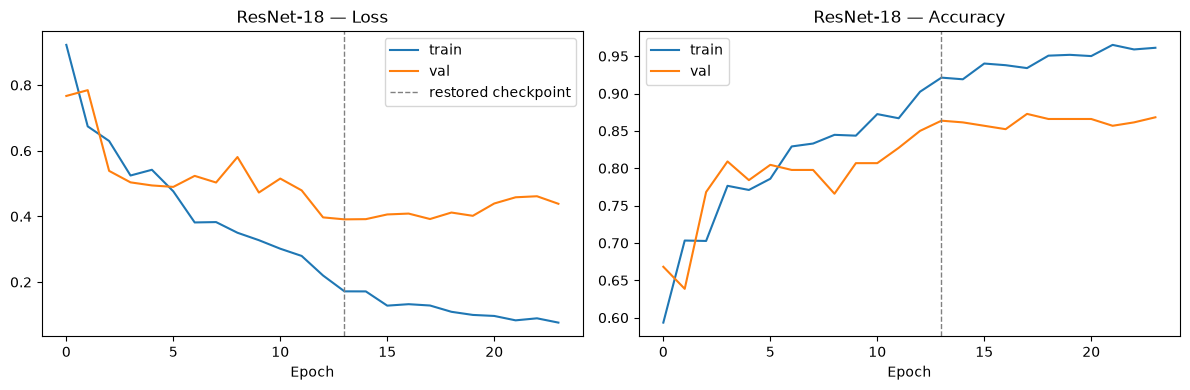

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "ResNet-18", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "ResNet-18")

## Evaluate on the test set

[ResNet-18] Test accuracy: 0.824


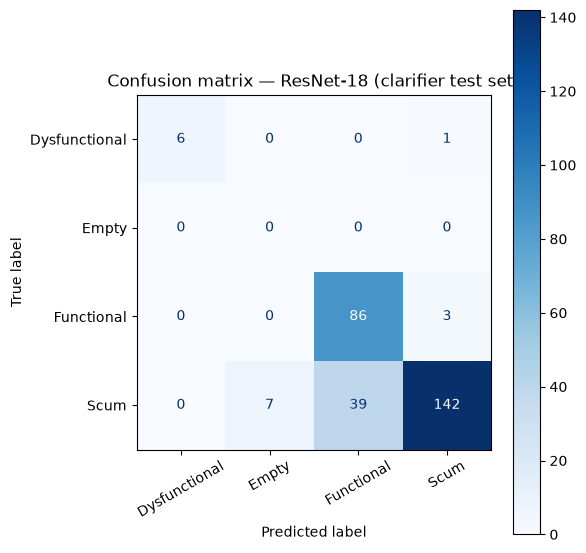

               precision    recall  f1-score   support

Dysfunctional      1.000     0.857     0.923         7
        Empty      0.000     0.000     0.000         0
   Functional      0.688     0.966     0.804        89
         Scum      0.973     0.755     0.850       188

     accuracy                          0.824       284
    macro avg      0.665     0.645     0.644       284
 weighted avg      0.884     0.824     0.838       284

  [warn] 'Empty' has 0 examples in this test set — AUC undefined, skipping.


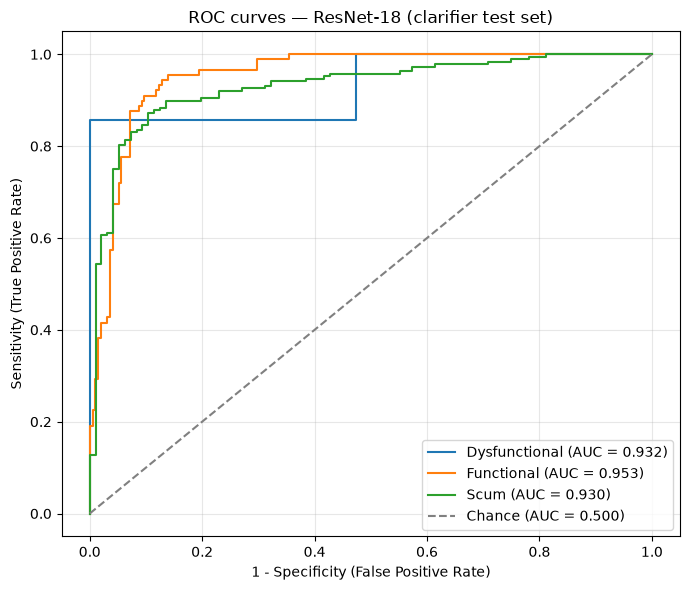

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.932
  Empty          : undefined (0 examples)
  Functional     : 0.953
  Scum           : 0.930

Mean AUC (over 3/4 classes with test examples): 0.938


(np.float64(0.823943661971831),
 {'Dysfunctional': 0.9324394017534812,
  'Empty': nan,
  'Functional': 0.9529242293287237,
  'Scum': 0.9298537234042554})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "ResNet-18", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

This is the step the results notebook depends on — it pickles the metrics/history and saves the model state dict so nothing needs to be kept in memory or re-trained.

In [6]:
save_result("ResNet-18", "resnet18")

Saved results to ../results/clarifier_aug/results_clarifier_resnet18_Waterval.pkl


Saved model weights to ../models/clarifier_resnet18_cnn.pt
